In [1]:
from typing import (
    Callable,
    Dict,
    Tuple,
)

import torch
from torch import Tensor, nn
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split

from src import dataset
from src.models import mk_model
from src.dataset import load_preprocessed_dataset
from src.configs import TrainingConfig, ModelConfig, DatasetConfig, DEVICE, PIXEL_VALUE_CHANNEL_IDX

In [2]:
dataset.mk_dataset(verbose=False)
train_cfg = TrainingConfig()
model_cfg = ModelConfig()
dataset_cfg = DatasetConfig()

x_train, y_train, x_test = load_preprocessed_dataset()
model = mk_model(model_cfg)
x_ds = torch.utils.data.TensorDataset(torch.cat((x_train, x_test)).to(DEVICE))
x_dl = DataLoader(x_ds, train_cfg.batch_size)
ssl_transform = v2.RandomAffine(degrees=(-10, 10), translate=(0.1, 0.3), scale=(0.75, 1))
optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg.starting_lr)

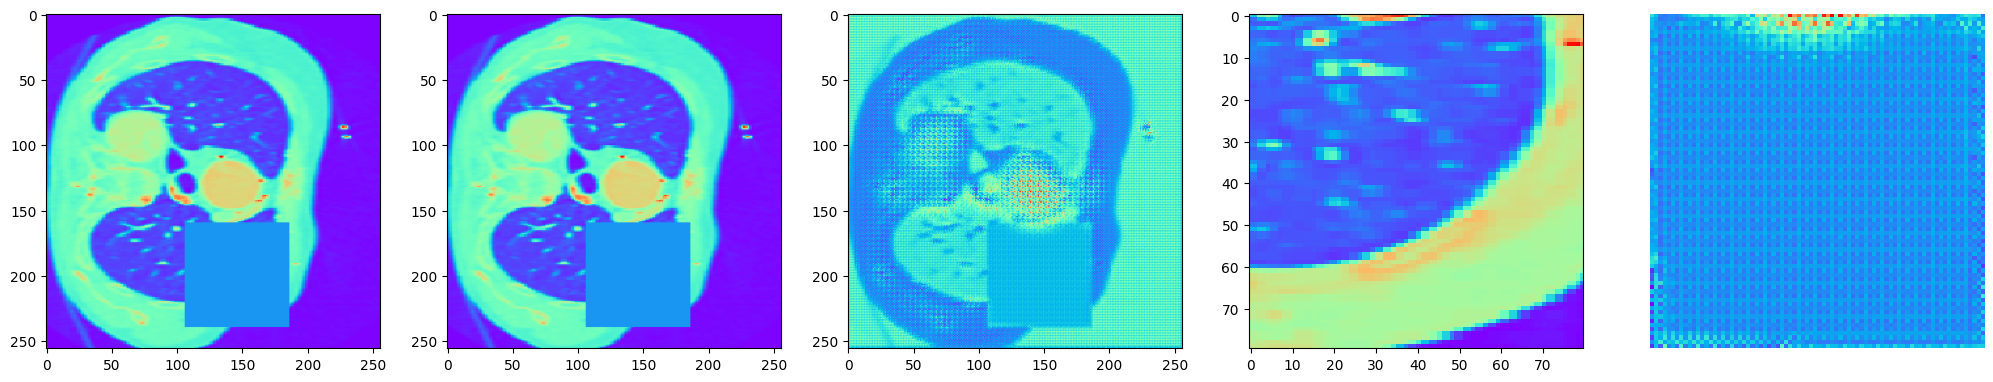

tensor(0.9989, device='cuda:0', grad_fn=<MseLossBackward0>)


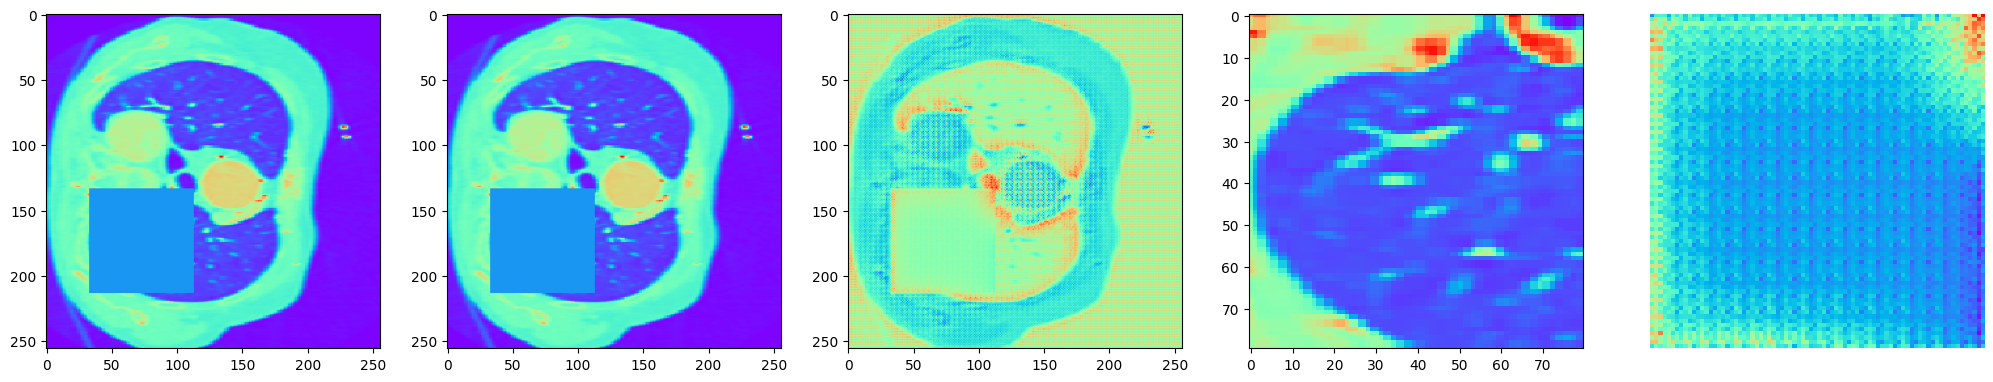

tensor(0.7399, device='cuda:0', grad_fn=<MseLossBackward0>)


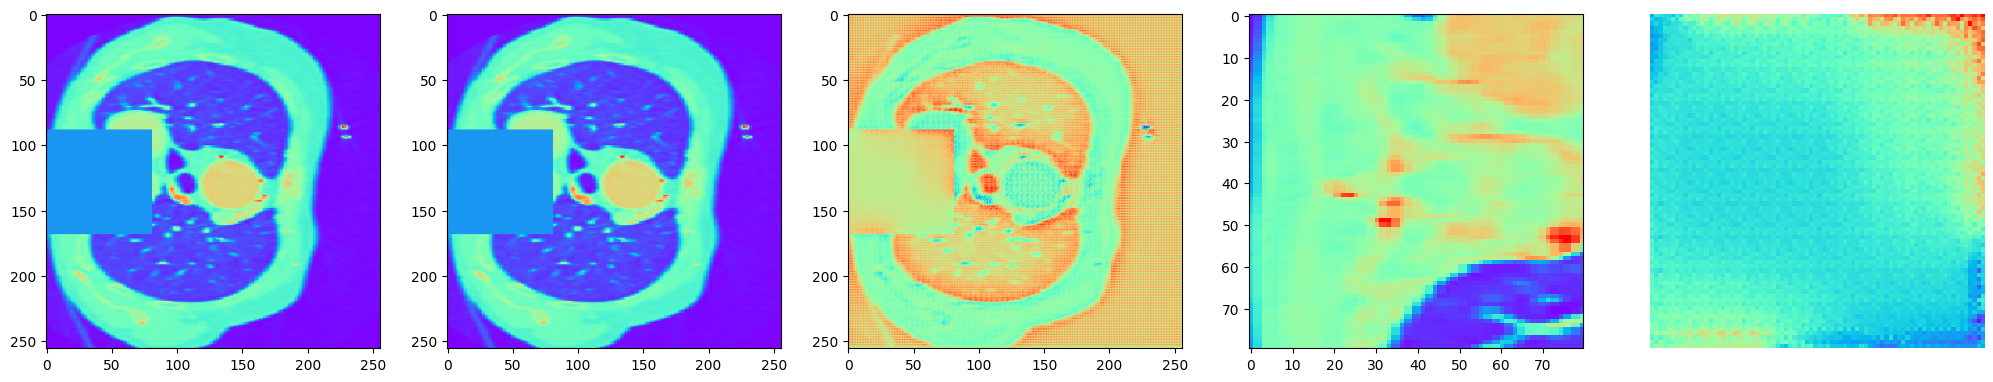

tensor(0.8092, device='cuda:0', grad_fn=<MseLossBackward0>)


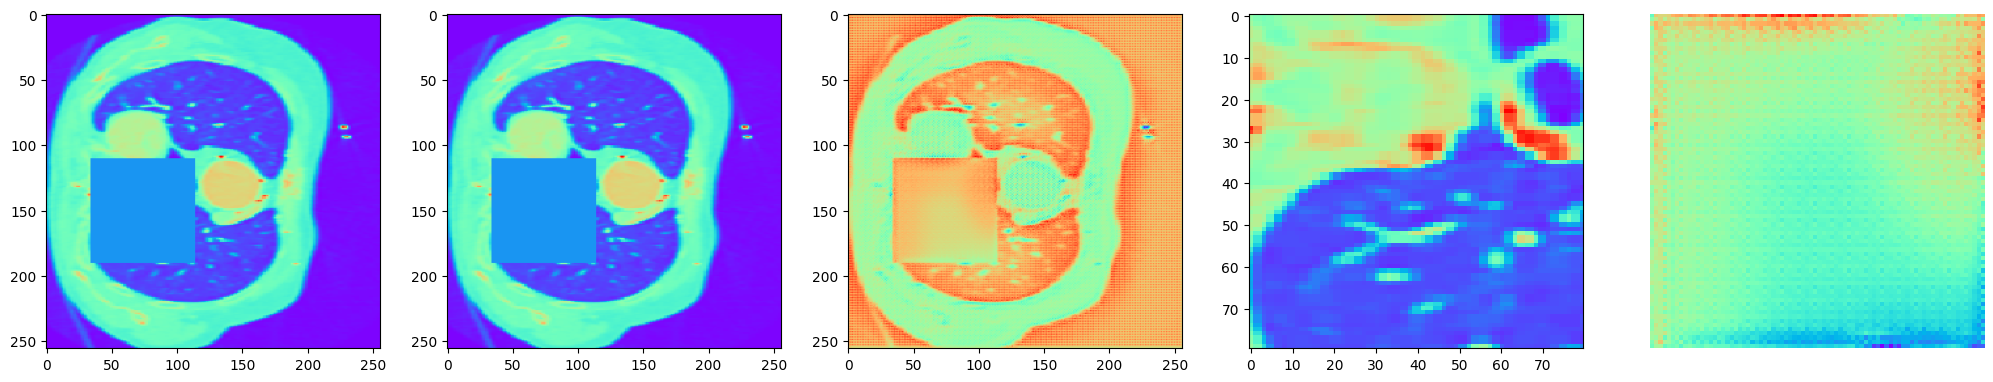

tensor(0.7327, device='cuda:0', grad_fn=<MseLossBackward0>)


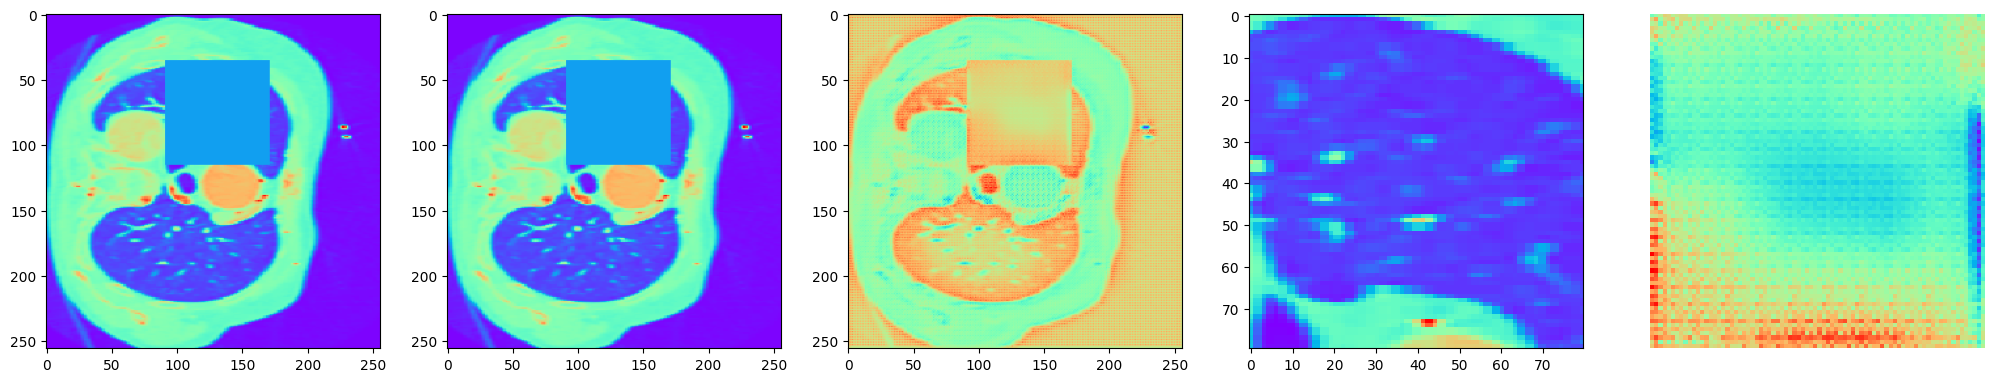

tensor(0.6020, device='cuda:0', grad_fn=<MseLossBackward0>)


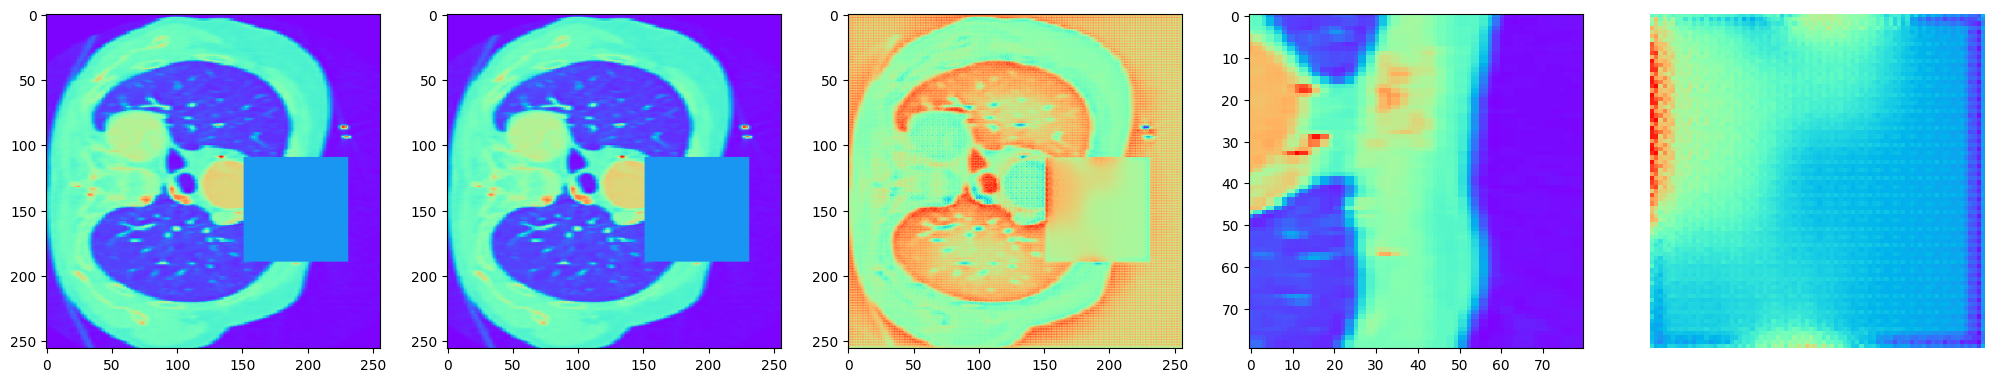

tensor(0.6229, device='cuda:0', grad_fn=<MseLossBackward0>)


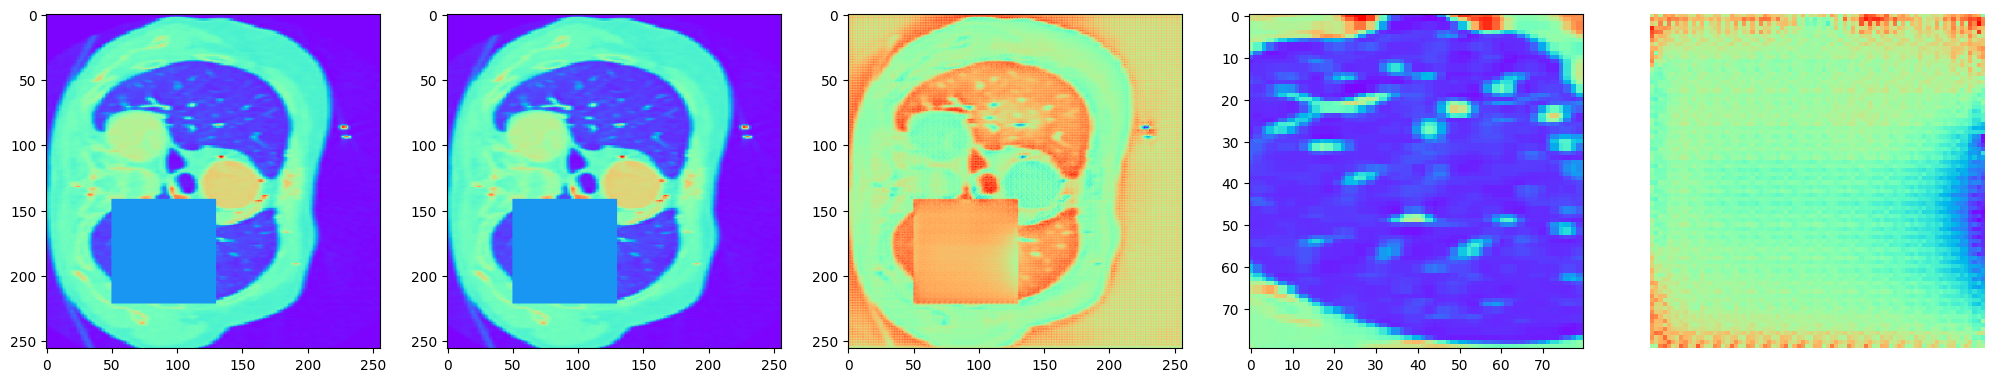

tensor(0.6938, device='cuda:0', grad_fn=<MseLossBackward0>)


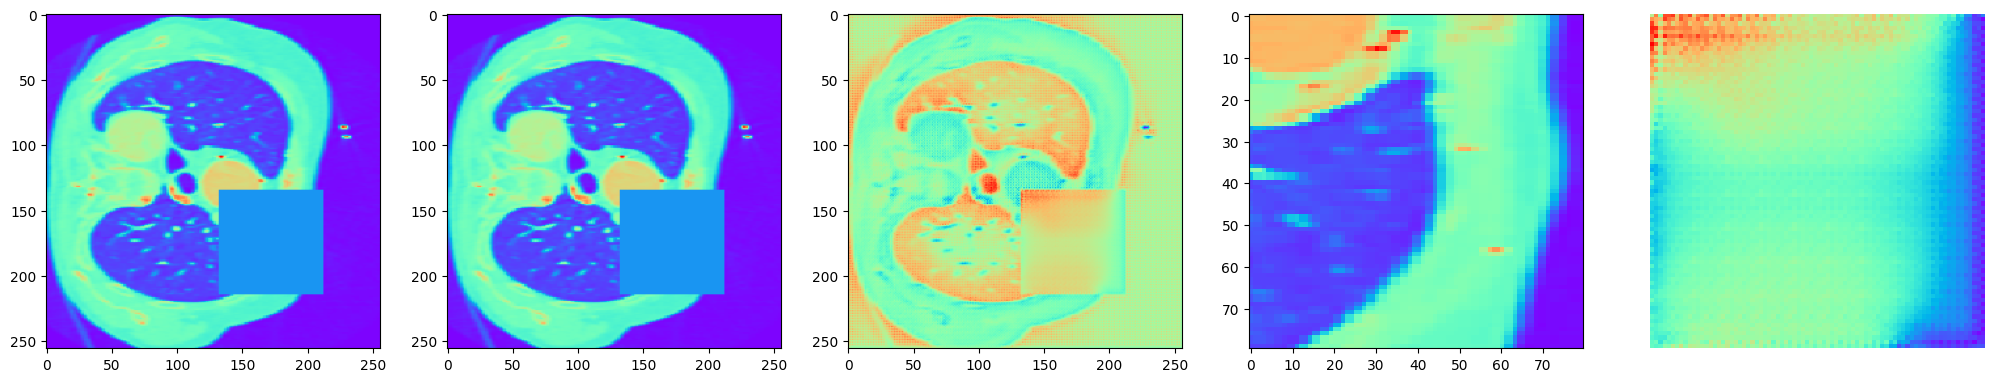

tensor(0.5779, device='cuda:0', grad_fn=<MseLossBackward0>)


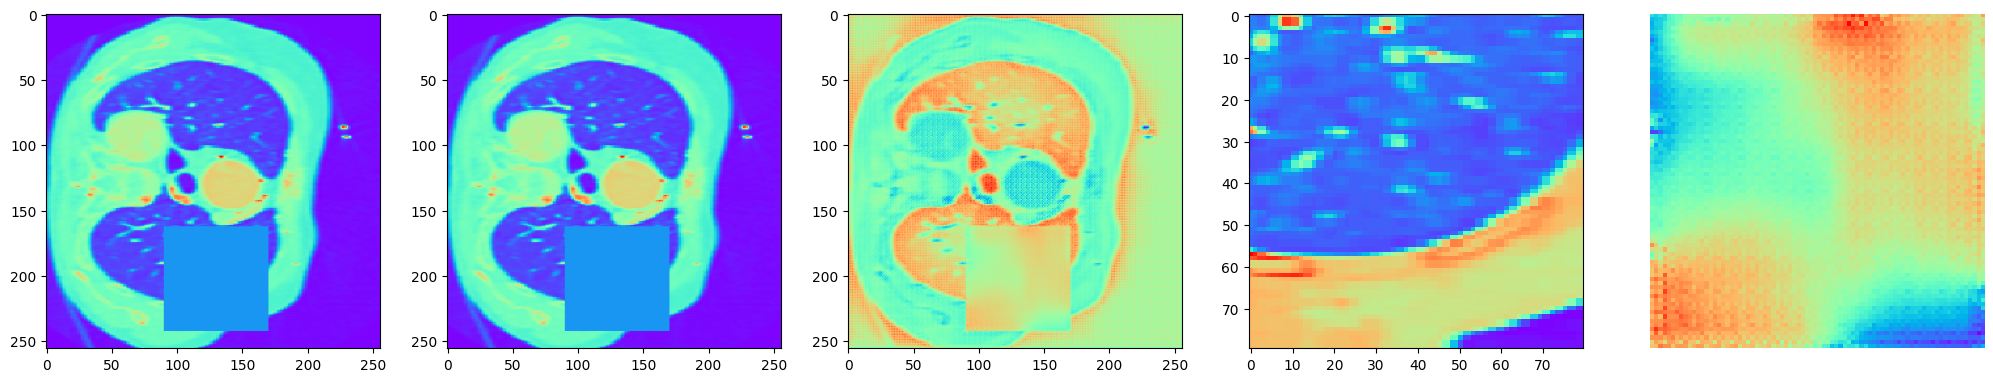

tensor(0.5107, device='cuda:0', grad_fn=<MseLossBackward0>)


In [ ]:
from copy import deepcopy
from random import randint

import matplotlib.pyplot as plt


criterion_ret_t = Tuple[Tensor, Dict[str, Tensor]]
criterion_t = Callable[[Tensor, Tensor], criterion_ret_t]


def ssl_train_model_for_single_epoch(
        x_dl: DataLoader,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        mask_size: int,
        transform: callable,
    ):
    for i, (x, ) in enumerate(x_dl):
        mask_slices = mk_mask_slices(mask_size)
        og_x = x.detach()
        x, x_target = get_augmeted_x_and_target(x, mask_slices, transform)
        def criterion(x_pred: Tensor, x_target: Tensor) -> criterion_ret_t:
            x_target_pred = x_pred[:, PIXEL_VALUE_CHANNEL_IDX, mask_slices[0], mask_slices[1]]
            loss = torch.nn.functional.mse_loss(x_target_pred, x_target)
            return loss, {"mse_loss": loss, "x_target_pred": x_target_pred, "x_target": x_target}
        step_info, y_pred_logits = model_step(model, x, x_target, optimizer, criterion)
        if i == len(x_dl) - 1:
            plt_step(
                og_x,
                x,
                y_pred_logits[:, PIXEL_VALUE_CHANNEL_IDX],
                step_info["x_target"],
                step_info["x_target_pred"],
            )
            print(step_info["mse_loss"])

def model_step(
        model: nn.Module,
        x: Tensor,
        y_true: Tensor,
        optimizer: torch.optim.Optimizer,
        criterion: criterion_t
    ) -> dict[str, Tensor]:
    optimizer.zero_grad()
    with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
        y_pred_logits = model(x)
        loss, losses = criterion(y_pred_logits, y_true)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return losses, y_pred_logits

MAX_SAMPLES_TO_PLOT = 1
def plt_step(*tensors: list[Tensor]):
    b_size = tensors[0].shape[0]
    b_size = min(b_size, MAX_SAMPLES_TO_PLOT)
    fig, axes = plt.subplots(
        b_size,
        len(tensors),
        squeeze=False,
    )
    fig = fig.set_size_inches(5 * len(tensors), 10)
    for tensor_idx, tensor in enumerate(tensors):
        samples = tensor[:b_size]
        for sample_idx, sample in enumerate(samples):
            ax = axes[sample_idx, tensor_idx]
            sample = (
                sample
                .squeeze()
                .detach()
                .to(device="cpu", dtype=torch.float)
                .numpy()
            )
            ax.imshow(sample, cmap="rainbow")
    plt.axis("off")
    plt.show()

def get_augmeted_x_and_target(
        x: Tensor,
        mask_slices: tuple[slice, slice],
        transform: v2.Transform,
    ) -> tuple[Tensor, Tensor]:
    # x = transform(x)
    x_target = deepcopy(x[:, 0, mask_slices[0], mask_slices[1]]).detach()
    x[:, 0, mask_slices[0], mask_slices[1]] = 0
    return x, x_target

def mk_mask_slices(mask_size: int) -> tuple[slice, slice]:
    h_start = randint(0, 256 - mask_size)
    w_start = randint(0, 256 - mask_size)
    w_slice = slice(h_start, h_start + mask_size)
    h_slice = slice(w_start, w_start + mask_size)
    return w_slice, h_slice

for _ in range(500):
    ssl_train_model_for_single_epoch(x_dl, model, optimizer, 80, ssl_transform)